In [1]:
import os
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import json
import numpy as np
import torch
import torch.nn as nn
import copy
import time

/home/adgomezm/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Models generated by random sampling

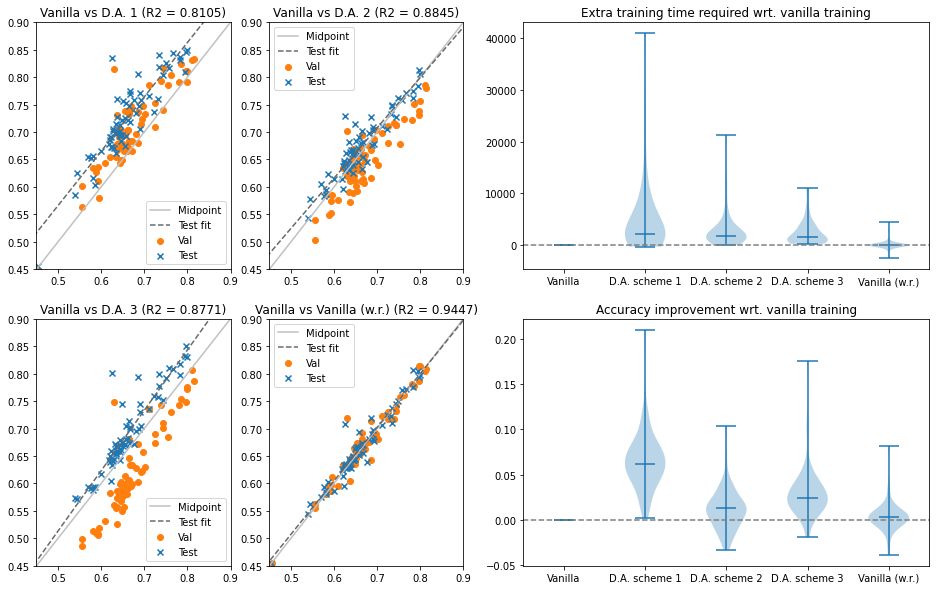

In [2]:
# Load results
if os.path.exists('tr_accs.json'):
    with open('tr_accs.json', 'r') as file:
        tr_accs = json.load(file)
    with open('val_accs.json', 'r') as file:
        val_accs = json.load(file)
    with open('test_accs.json', 'r') as file:
        test_accs = json.load(file)
    with open('train_times.json', 'r') as file:
        train_times = json.load(file)

# Create numpy arrays
test_van = np.array([test for test in test_accs["vanilla"] if test != None])
test_da1 = np.array([test for test in test_accs["daug1"] if test != None])
test_da2 = np.array([test for test in test_accs["daug2"] if test != None])
test_da3 = np.array([test for test in test_accs["daug3"] if test != None])
test_rew = np.array([test for test in test_accs["reinit"] if test != None])
val_van = np.array([val for val in val_accs["vanilla"] if val != None])
val_da1 = np.array([val for val in val_accs["daug1"] if val != None])
val_da2 = np.array([val for val in val_accs["daug2"] if val != None])
val_da3 = np.array([val for val in val_accs["daug3"] if val != None])
val_rew = np.array([val for val in val_accs["reinit"] if val != None])
times_van = np.array([time for time in train_times["vanilla"] if time != None])
times_da1 = np.array([time for time in train_times["daug1"] if time != None])
times_da2 = np.array([time for time in train_times["daug2"] if time != None])
times_da3 = np.array([time for time in train_times["daug3"] if time != None])
times_rew = np.array([time for time in train_times["reinit"] if time != None])

# Check correlation between attained accuracies in test
reg1 = LinearRegression().fit(test_van.reshape(-1, 1),test_da1.reshape(-1, 1))
R2_1 = round(reg1.score(test_van.reshape(-1, 1),test_da1.reshape(-1, 1)), 4)
reg2 = LinearRegression().fit(test_van.reshape(-1, 1),test_da2.reshape(-1, 1))
R2_2 = round(reg2.score(test_van.reshape(-1, 1),test_da2.reshape(-1, 1)), 4)
reg3 = LinearRegression().fit(test_van.reshape(-1, 1),test_da3.reshape(-1, 1))
R2_3 = round(reg3.score(test_van.reshape(-1, 1),test_da3.reshape(-1, 1)), 4)
reg4 = LinearRegression().fit(test_van.reshape(-1, 1),test_rew.reshape(-1, 1))
R2_4 = round(reg4.score(test_van.reshape(-1, 1),test_rew.reshape(-1, 1)), 4)

# Calculate train time and performance differences model-wise to plot them later
diff1 = []
diff2 = []
diff3 = []
diff4 = []
for i, t in enumerate(test_van):
    diff1 += [test_da1[i]-t]
    diff2 += [test_da2[i]-t]
    diff3 += [test_da3[i]-t]
    diff4 += [test_rew[i]-t]
difft1 = []
difft2 = []
difft3 = []
difft4 = []
for i, t in enumerate(times_van):
    difft1 += [times_da1[i]-t]
    difft2 += [times_da2[i]-t]
    difft3 += [times_da3[i]-t]
    difft4 += [times_rew[i]-t]
    
plt.figure(figsize = (16,10))

plt.subplot(241)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg1.intercept_[0], reg1.intercept_[0]+reg1.coef_[0][0]], "--", c="dimgray")
plt.scatter(val_van, val_da1, c = "tab:orange")
plt.scatter(test_van, test_da1, marker = "x", c = "tab:blue")
plt.legend(["Midpoint", "Test fit", "Val", "Test"])
plt.title("Vanilla vs D.A. 1 (R2 = "+str(R2_1)+")")
lims = [np.min(np.concatenate((val_van,val_da1,test_van,test_da1)))-0.05, np.min([1, np.max(np.concatenate((val_van,val_da1,test_van,test_da1)))+0.05])]
lims = [0.45, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(242)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg2.intercept_[0], reg2.intercept_[0]+reg2.coef_[0][0]], "--", c="dimgray")
plt.scatter(val_van, val_da2, c = "tab:orange")
plt.scatter(test_van, test_da2, marker = "x", c = "tab:blue")
plt.legend(["Midpoint", "Test fit", "Val", "Test"])
plt.title("Vanilla vs D.A. 2 (R2 = "+str(R2_2)+")")
lims = [np.min(np.concatenate((val_van,val_da2,test_van,test_da2)))-0.05, np.min([1, np.max(np.concatenate((val_van,val_da2,test_van,test_da2)))+0.05])]
lims = [0.45, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(245)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg3.intercept_[0], reg3.intercept_[0]+reg3.coef_[0][0]], "--", c="dimgray")
plt.scatter(val_van, val_da3, c = "tab:orange")
plt.scatter(test_van, test_da3, marker = "x", c = "tab:blue")
plt.legend(["Midpoint", "Test fit", "Val", "Test"])
plt.title("Vanilla vs D.A. 3 (R2 = "+str(R2_3)+")")
lims = [np.min(np.concatenate((val_van,val_da3,test_van,test_da3)))-0.05, np.min([1, np.max(np.concatenate((val_van,val_da3,test_van,test_da3)))+0.05])]
lims = [0.45, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(246)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg4.intercept_[0], reg4.intercept_[0]+reg4.coef_[0][0]], "--", c="dimgray")
plt.scatter(val_van, val_rew, c = "tab:orange")
plt.scatter(test_van, test_rew, marker = "x", c = "tab:blue")
plt.legend(["Midpoint", "Test fit", "Val", "Test"])
plt.title("Vanilla vs Vanilla (w.r.) (R2 = "+str(R2_4)+")")
lims = [np.min(np.concatenate((val_van,val_rew,test_van,test_rew)))-0.05, np.min([1, np.max(np.concatenate((val_van,val_rew,test_van,test_rew)))+0.05])]
lims = [0.45, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(222)
plt.violinplot([[0], difft1, difft2, difft3, difft4], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Extra training time required wrt. vanilla training")

plt.subplot(224)
plt.violinplot([[0], diff1, diff2, diff3, diff4], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Accuracy improvement wrt. vanilla training")
plt.show()

In [4]:
times_van

array([  339.84492755,   169.39634633,   500.41973829,  2342.25703049,
        1973.49270368,  1210.02545619,  3441.3334403 ,   299.51072264,
       16083.36187959,  1993.52288485,  4256.00878119,   255.6781404 ,
        3762.50478387,  3708.2602663 ,  5903.61755371,   228.99623942,
        3657.84823704,   148.67753029,   937.21506524,  1421.65204477,
        3481.65998125,   930.34717703,  2815.59532666,  4948.1027565 ,
         571.53696823,   341.64908218,  6513.5980792 ,   669.74361849,
        2295.29946184,   730.46778059,  2936.51903272,  8045.17947507,
        2397.45172381, 11475.320261  ,   572.7686193 ,   196.20432901,
        3309.87855411,  1162.32420802,   171.98853683,   497.771945  ,
         655.06877923,  4073.41898155,   696.52523804,  1784.70715928,
         317.12411356,  1528.74476075,   462.70748401,   182.34326196,
        1715.35485196,  7160.23574877,  3726.44121456,  2789.20182824,
         167.08044457,   284.55176544,  9534.07923126,   874.54050136,
      

# Models generated via mutation

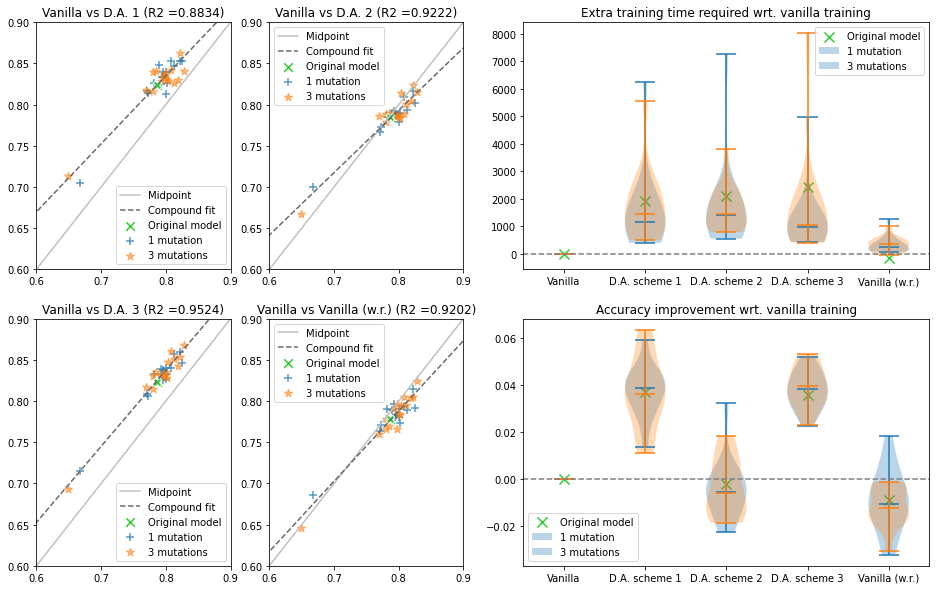

In [3]:
# Load results
original_model_stats = {'train': [0.9165111940298507, 0.8478144989339019, 0.8374200426439232, 0.8678704690831557, 0.8853500355366027],
                        'val': [0.7949256238003839, 0.794525751759437, 0.7439419385796545, 0.7687739923224568, 0.7977047344849648],
                        'test': [0.786841054313099, 0.8238817891373802, 0.7845447284345048, 0.8225838658146964, 0.7778554313099042],
                        "times": [1112.1779091358185, 3015.4224519729614, 3211.763417005539, 3535.628020763397, 952.5548124313354]}

if os.path.exists('tr_accs_1mut.json'):
    with open('tr_accs_1mut.json', 'r') as file:
        tr_accs_1mut = json.load(file)
    with open('val_accs_1mut.json', 'r') as file:
        val_accs_1mut = json.load(file)
    with open('test_accs_1mut.json', 'r') as file:
        test_accs_1mut = json.load(file)
    with open('train_times_1mut.json', 'r') as file:
        train_times_1mut = json.load(file)

if os.path.exists('tr_accs_3mut.json'):
    with open('tr_accs_3mut.json', 'r') as file:
        tr_accs_3mut = json.load(file)
    with open('val_accs_3mut.json', 'r') as file:
        val_accs_3mut = json.load(file)
    with open('test_accs_3mut.json', 'r') as file:
        test_accs_3mut = json.load(file)
    with open('train_times_3mut.json', 'r') as file:
        train_times_3mut = json.load(file)

# Create np arrays
test_van_1mut = np.array([test for test in test_accs_1mut["vanilla"] if test != None])
test_da1_1mut = np.array([test for test in test_accs_1mut["daug1"] if test != None])
test_da2_1mut = np.array([test for test in test_accs_1mut["daug2"] if test != None])
test_da3_1mut = np.array([test for test in test_accs_1mut["daug3"] if test != None])
test_rew_1mut = np.array([test for test in test_accs_1mut["reinit"] if test != None])
val_van_1mut = np.array([val for val in val_accs_1mut["vanilla"] if val != None])
val_da1_1mut = np.array([val for val in val_accs_1mut["daug1"] if val != None])
val_da2_1mut = np.array([val for val in val_accs_1mut["daug2"] if val != None])
val_da3_1mut = np.array([val for val in val_accs_1mut["daug3"] if val != None])
val_rew_1mut = np.array([val for val in val_accs_1mut["reinit"] if val != None])
times_van_1mut = np.array([time for time in train_times_1mut["vanilla"] if time != None])
times_da1_1mut = np.array([time for time in train_times_1mut["daug1"] if time != None])
times_da2_1mut = np.array([time for time in train_times_1mut["daug2"] if time != None])
times_da3_1mut = np.array([time for time in train_times_1mut["daug3"] if time != None])
times_rew_1mut = np.array([time for time in train_times_1mut["reinit"] if time != None])

test_van_3mut = np.array([test for test in test_accs_3mut["vanilla"] if test != None])
test_da1_3mut = np.array([test for test in test_accs_3mut["daug1"] if test != None])
test_da2_3mut = np.array([test for test in test_accs_3mut["daug2"] if test != None])
test_da3_3mut = np.array([test for test in test_accs_3mut["daug3"] if test != None])
test_rew_3mut = np.array([test for test in test_accs_3mut["reinit"] if test != None])
val_van_3mut = np.array([val for val in val_accs_3mut["vanilla"] if val != None])
val_da1_3mut = np.array([val for val in val_accs_3mut["daug1"] if val != None])
val_da2_3mut = np.array([val for val in val_accs_3mut["daug2"] if val != None])
val_da3_3mut = np.array([val for val in val_accs_3mut["daug3"] if val != None])
val_rew_3mut = np.array([val for val in val_accs_3mut["reinit"] if val != None])
times_van_3mut = np.array([time for time in train_times_3mut["vanilla"] if time != None])
times_da1_3mut = np.array([time for time in train_times_3mut["daug1"] if time != None])
times_da2_3mut = np.array([time for time in train_times_3mut["daug2"] if time != None])
times_da3_3mut = np.array([time for time in train_times_3mut["daug3"] if time != None])
times_rew_3mut = np.array([time for time in train_times_3mut["reinit"] if time != None])


# Check correlation between attained accuracies in test
reg1 = LinearRegression().fit(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da1_1mut, test_da1_3mut)).reshape(-1, 1))
R2_1 = round(reg1.score(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da1_1mut, test_da1_3mut)).reshape(-1, 1)), 4)
reg2 = LinearRegression().fit(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da2_1mut, test_da2_3mut)).reshape(-1, 1))
R2_2 = round(reg2.score(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da2_1mut, test_da2_3mut)).reshape(-1, 1)), 4)
reg3 = LinearRegression().fit(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da3_1mut, test_da3_3mut)).reshape(-1, 1))
R2_3 = round(reg3.score(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_da3_1mut, test_da3_3mut)).reshape(-1, 1)), 4)
reg4 = LinearRegression().fit(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_rew_1mut, test_rew_3mut)).reshape(-1, 1))
R2_4 = round(reg4.score(np.concatenate((test_van_1mut, test_van_3mut)).reshape(-1, 1),np.concatenate((test_rew_1mut, test_rew_3mut)).reshape(-1, 1)), 4)


# Calculate train time and performance differences model-wise to plot them later
diff1_1mut = []
diff2_1mut = []
diff3_1mut = []
diff4_1mut = []
for i, t in enumerate(test_van_1mut):
    diff1_1mut += [test_da1_1mut[i]-t]
    diff2_1mut += [test_da2_1mut[i]-t]
    diff3_1mut += [test_da3_1mut[i]-t]
    diff4_1mut += [test_rew_1mut[i]-t]
difft1_1mut = []
difft2_1mut = []
difft3_1mut = []
difft4_1mut = []
for i, t in enumerate(times_van_1mut):
    difft1_1mut += [times_da1_1mut[i]-t]
    difft2_1mut += [times_da2_1mut[i]-t]
    difft3_1mut += [times_da3_1mut[i]-t]
    difft4_1mut += [times_rew_1mut[i]-t]

diff1_3mut = []
diff2_3mut = []
diff3_3mut = []
diff4_3mut = []
for i, t in enumerate(test_van_3mut):
    diff1_3mut += [test_da1_3mut[i]-t]
    diff2_3mut += [test_da2_3mut[i]-t]
    diff3_3mut += [test_da3_3mut[i]-t]
    diff4_3mut += [test_rew_3mut[i]-t]
difft1_3mut = []
difft2_3mut = []
difft3_3mut = []
difft4_3mut = []
for i, t in enumerate(times_van_3mut):
    difft1_3mut += [times_da1_3mut[i]-t]
    difft2_3mut += [times_da2_3mut[i]-t]
    difft3_3mut += [times_da3_3mut[i]-t]
    difft4_3mut += [times_rew_3mut[i]-t]

plt.figure(figsize = (16,10))

plt.subplot(241)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg1.intercept_[0], reg1.intercept_[0]+reg1.coef_[0][0]], "--", c="dimgray")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][1]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da1_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da1_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][1]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.legend(["Midpoint", "Compound fit", "Original model", "1 mutation", "3 mutations"])
plt.title("Vanilla vs D.A. 1 (R2 ="+str(R2_1)+")")
lims = [np.min(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))-0.05, np.min([1, np.max(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))+0.05])]
lims = [0.6, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(242)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg2.intercept_[0], reg2.intercept_[0]+reg2.coef_[0][0]], "--", c="dimgray")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][2]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da2_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da2_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][2]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.legend(["Midpoint", "Compound fit", "Original model", "1 mutation", "3 mutations"])
plt.title("Vanilla vs D.A. 2 (R2 ="+str(R2_2)+")")
lims = [np.min(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))-0.05, np.min([1, np.max(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))+0.05])]
lims = [0.6, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(245)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg3.intercept_[0], reg3.intercept_[0]+reg3.coef_[0][0]], "--", c="dimgray")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][3]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_da3_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_da3_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][3]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.legend(["Midpoint", "Compound fit", "Original model", "1 mutation", "3 mutations"])
plt.title("Vanilla vs D.A. 3 (R2 ="+str(R2_3)+")")
lims = [np.min(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))-0.05, np.min([1, np.max(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))+0.05])]
lims = [0.6, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(246)
plt.plot([0,1],[0,1], c="silver")
plt.plot([0,1],[reg4.intercept_[0], reg4.intercept_[0]+reg4.coef_[0][0]], "--", c="dimgray")
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][4]], s = 75, marker = "x", c = "limegreen")
plt.scatter(test_van_1mut, test_rew_1mut, marker = "+", c = "tab:blue", alpha=0.75, s = 75)
plt.scatter(test_van_3mut, test_rew_3mut, marker = "*", c = "tab:orange", alpha=0.55, s = 75)
plt.scatter([original_model_stats["test"][0]], [original_model_stats["test"][4]], s = 75, marker = "X", c = "limegreen", edgecolors = "w")
plt.legend(["Midpoint", "Compound fit", "Original model", "1 mutation", "3 mutations"])
plt.title("Vanilla vs Vanilla (w.r.) (R2 ="+str(R2_4)+")")
lims = [np.min(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))-0.05, np.min([1, np.max(np.concatenate((val_van_1mut,val_da1_1mut,test_van_1mut,test_da1_1mut)))+0.05])]
lims = [0.6, 0.9]
plt.xlim(lims)
plt.ylim(lims)

plt.subplot(222)
plt.scatter([1, 2, 3, 4, 5], [0, original_model_stats["times"][1]-original_model_stats["times"][0], original_model_stats["times"][2]-original_model_stats["times"][0], original_model_stats["times"][3]-original_model_stats["times"][0], original_model_stats["times"][4]-original_model_stats["times"][0]], s = 100, marker = "x", c = "limegreen")
plt.violinplot([[0], difft1_1mut, difft2_1mut, difft3_1mut, difft4_1mut], showmedians = True)
plt.violinplot([[0], difft1_3mut, difft2_3mut, difft3_3mut, difft4_3mut], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.legend(["Original model", "1 mutation", "3 mutations"])
plt.title("Extra training time required wrt. vanilla training")

plt.subplot(224)
plt.scatter([1, 2, 3, 4, 5], [0, original_model_stats["test"][1]-original_model_stats["test"][0], original_model_stats["test"][2]-original_model_stats["test"][0], original_model_stats["test"][3]-original_model_stats["test"][0], original_model_stats["test"][4]-original_model_stats["test"][0]], s = 100, marker = "x", c = "limegreen")
plt.violinplot([[0], diff1_1mut, diff2_1mut, diff3_1mut, diff4_1mut], showmedians = True)
plt.violinplot([[0], diff1_3mut, diff2_3mut, diff3_3mut, diff4_3mut], showmedians = True)
plt.gca().set_xticks([1,2,3,4,5])
plt.gca().set_xticklabels(["Vanilla", "D.A. scheme 1", "D.A. scheme 2", "D.A. scheme 3", "Vanilla (w.r.)"])
plt.plot([0,6],[0,0], "--", c = "tab:gray")
plt.xlim([0.5, 5.5])
plt.title("Accuracy improvement wrt. vanilla training")
plt.legend(["Original model", "1 mutation", "3 mutations"])
plt.show()